In [1]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.dpot import DPOT
from context_flux_no.training import PDEDataset
from context_flux_no.training.loader import SegmentLoader
from jaxtyping import Array, Float

# jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_captured_constants_report_frames", -1)


In [2]:
dpot = DPOT(
    num_spatial_dims=1,
    in_channels=1,
    out_channels=1,
    in_timesteps=20,
    patch_size=(4,),
    img_size=(100,),
    embedding_dim=256,
    max_frequency_modes=(10,),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=256,
    hidden_dim_fno=256,
    hidden_dim_output=32,
    key=jax.random.key(0),
)

In [3]:
img_1d = jnp.ones((20, 1, 100))
dpot(img_1d)[0].shape

(1, 100)

In [4]:
# jax.config.update("jax_enable_x64", True)

datadir = Path("./data")
dataset_xr = xr.load_dataset(datadir / "cubic_no_source_large_train.hdf5")
# dataset_xr = xr.open_mfdataset(
#     sorted(list(datadir.glob("cubic_no_source_large_train_seed=*.hdf5"))),
#     combine="nested",
#     concat_dim="pde",
#     engine="h5netcdf",
# )
dataset_xr

<xarray.Dataset> Size: 40GB
Dimensions:  (pde: 1000, ic: 100, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float32 40GB 0.3343 0.219 ... -0.4966 -0.5188
    coeffs   (pde, param) float32 12kB -0.8828 -0.9787 ... -0.5751 -0.03708

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)
/home/jhko725/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


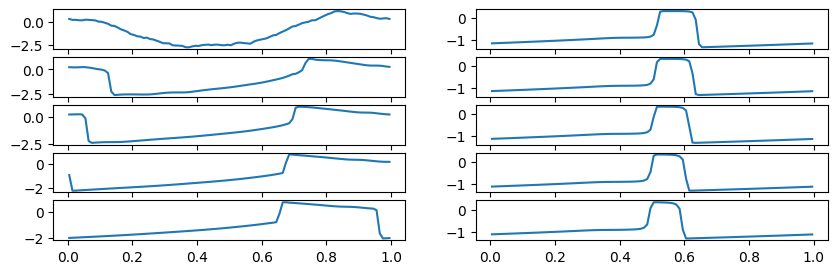

In [5]:
# Do the downsampling before on the dask arrays to make things speedier
dataset_train, dataset_test = (
    PDEDataset.from_xarray(dataset_xr).downsample_time(10).split_by_time(80)
)

fig, axes = plt.subplots(5, 2, figsize=(10, 3))
for i in range(axes.shape[0]):
    axes[i, 0].plot(dataset_train.x, dataset_train.u[0, 0, i * 4, 0])
    axes[i, 1].plot(dataset_test.x, dataset_test.u[0, 0, i * 4, 0])

In [6]:
loader = SegmentLoader(dataset_train, segment_length=21, batch_size=1024)
batch, _ = loader.load_batch(loader.init())

In [7]:
batch[1].shape

()

In [8]:
def loss_fn(
    model, batch: tuple[Float[Array, "..."], ...]
) -> tuple[Float[Array, ""], dict]:
    u, dt, dx = batch
    u0, u1 = u[:, :-1], u[:, -1]
    u1_pred = eqx.filter_vmap(model)(u0)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


In [9]:
loss_fn(dpot, batch)

2026-01-19 22:21:26.908699: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 43.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-19 22:21:30.312384: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 33.53GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-19 22:21:31.138486: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-19 22:21:31.338009: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. T

(Array(0.748401, dtype=float32), {})

In [10]:
from context_flux_no.utils import num_parameters


num_parameters(dpot)

2383469

In [11]:
def train(
    model,
    dataloader: SegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn,
    max_steps: int,
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_):
        batch, loader_state_next = dataloader.load_batch(loader_state_)
        (loss, aux), grads = loss_grad_fn(model_, batch)
        updates, opt_state_next = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_next, opt_state_next

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_history = []
    try:
        for i in range(max_steps):
            loss, aux, model, loader_state, opt_state = train_step(
                model, loader_state, opt_state
            )

            loss_scalar = loss.item()
            print(f"Step: {i}: loss = {loss_scalar}")
            loss_history.append(loss_scalar)
    finally:
        return model, jnp.asarray(loss_history)

In [12]:
optimizer = optax.adamw(1e-3)
model, loss_history = train(dpot, loader, optimizer, loss_fn, max_steps=5000)

/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1132: UserWarning: A large amount of constants were captured during lowering (3.20GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)
2026-01-19 22:23:34.671456: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 43.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-19 22:23:35.158176: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-19 22:23:35.357905: E external

Step: 0: loss = 0.7484009861946106
Step: 1: loss = 0.6433759927749634
Step: 2: loss = 0.4840557277202606
Step: 3: loss = 0.3572748601436615
Step: 4: loss = 0.2425369769334793
Step: 5: loss = 0.14369426667690277
Step: 6: loss = 0.23442400991916656
Step: 7: loss = 0.18754972517490387
Step: 8: loss = 0.09490180015563965
Step: 9: loss = 0.09339502453804016
Step: 10: loss = 0.11664474010467529
Step: 11: loss = 0.11190786957740784
Step: 12: loss = 0.0943550392985344
Step: 13: loss = 0.07341664284467697
Step: 14: loss = 0.0697188675403595
Step: 15: loss = 0.08375021815299988
Step: 16: loss = 0.08501128852367401
Step: 17: loss = 0.06938395649194717
Step: 18: loss = 0.05496755614876747
Step: 19: loss = 0.057453054934740067
Step: 20: loss = 0.0612710565328598
Step: 21: loss = 0.06293272972106934
Step: 22: loss = 0.055930402129888535
Step: 23: loss = 0.04640495777130127
Step: 24: loss = 0.046540841460227966
Step: 25: loss = 0.047050561755895615
Step: 26: loss = 0.04823252186179161
Step: 27: loss 

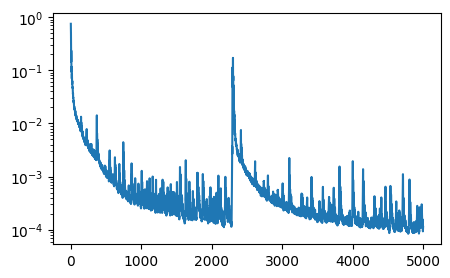

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log")

In [14]:
batch, _ = loader.load_batch(loader.init())
u1_pred = eqx.filter_vmap(model)(batch[0][:, :-1])


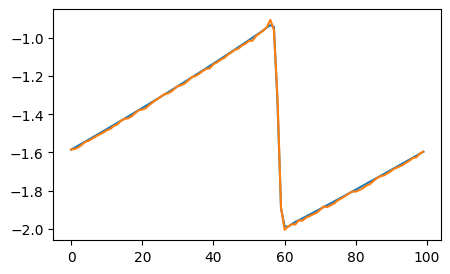

In [23]:
sample_ind = 5
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(batch[0][sample_ind, -1][0], label="Data")
ax.plot(u1_pred[0][sample_ind, 0], label="Pred")

In [23]:
batch[0][sample_ind, -1].shape

(1, 100)

In [29]:
u1_pred.shape

AttributeError: 'tuple' object has no attribute 'shape'